<a href="https://colab.research.google.com/github/beavenm/hit3001/blob/main/feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel("dataset4.xlsx")  # adjust path if needed

# Copy to preserve original
df_fe = df.copy()

# 🧠 Polymer-specific interaction features
df_fe["polymer1_logp_viscosity"] = df_fe["api_logp"] * df_fe["polymer_1_viscosity (cP)"]
df_fe["polymer2_logp_viscosity"] = df_fe["api_logp"] * df_fe["polymer_2_viscosity (cP)"]
df_fe["polymer3_logp_viscosity"] = df_fe["api_logp"] * df_fe["polymer_3_viscosity (cP)"]

df_fe["polymer1_logp_MW"] = df_fe["api_logp"] * df_fe["polymer_1_molecular_Weight_(g/mol)"]
df_fe["polymer2_logp_MW"] = df_fe["api_logp"] * df_fe["polymer_2_molecular_Weight_(g/mol)"]
df_fe["polymer3_logp_MW"] = df_fe["api_logp"] * df_fe["polymer_3_molecular_Weight_(g/mol)"]

# 🔁 General nonlinear features
df_fe["log_solubility"] = np.log1p(df_fe["api_water_solubility"])
df_fe["pka_squared"] = df_fe["api_pka"] ** 2
df_fe["conc_per_MW"] = df_fe["api_conc"] / df_fe["api_mw_g/mol"]

# ➗ Relative polymer composition
df_fe["total_polymer"] = (
    df_fe["polymer_1_ratio"] + df_fe["polymer_2_ratio"] + df_fe["polymer_3_ratio"]
)
df_fe["polymer1_frac"] = df_fe["polymer_1_ratio"] / df_fe["total_polymer"].replace(0, np.nan)
df_fe["polymer2_frac"] = df_fe["polymer_2_ratio"] / df_fe["total_polymer"].replace(0, np.nan)
df_fe["polymer3_frac"] = df_fe["polymer_3_ratio"] / df_fe["total_polymer"].replace(0, np.nan)

# 🧼 Clean up: replace NaNs from division
df_fe.fillna(0, inplace=True)

# ✅ Done: df_fe is your new feature-enhanced DataFrame
print("✅ Feature engineering complete. New shape:", df_fe.shape)
df_fe.head()


✅ Feature engineering complete. New shape: (151, 40)


,api_smile,api_mw_g/mol,api_logp,api_mp,api_pka,api_water_solubility,api_polar_surface_area_,api_conc,polymer_1_ratio,polymer_1_molecular_Weight_(g/mol),...,polymer1_logp_MW,polymer2_logp_MW,polymer3_logp_MW,log_solubility,pka_squared,conc_per_MW,total_polymer,polymer1_frac,polymer2_frac,polymer3_frac
0,CC1=CC=C(C=C1)C2=C(N3C=C(C=CC3=N2)C)CC(=O)N(C)...,764.9,3.02,196.0,5.65,0.0313,37.61,4.17,2.0,3500000,...,10570000.0,0.0,0.0,0.03082,31.9225,0.005452,2.0,1.0,0.0,0.0
1,CC1=CC=C(C=C1)C2=C(N3C=C(C=CC3=N2)C)CC(=O)N(C)...,764.9,3.02,196.0,5.65,0.0313,37.61,4.17,3.0,3500000,...,10570000.0,0.0,0.0,0.03082,31.9225,0.005452,3.0,1.0,0.0,0.0
2,CC1=CC=C(C=C1)C2=C(N3C=C(C=CC3=N2)C)CC(=O)N(C)...,764.9,3.02,196.0,5.65,0.0313,37.61,4.17,4.0,3500000,...,10570000.0,0.0,0.0,0.03082,31.9225,0.005452,4.0,1.0,0.0,0.0
3,CC1=CC=C(C=C1)C2=C(N3C=C(C=CC3=N2)C)CC(=O)N(C)...,764.9,3.02,196.0,5.65,0.0313,37.61,4.17,5.0,3500000,...,10570000.0,0.0,0.0,0.03082,31.9225,0.005452,5.0,1.0,0.0,0.0
4,CC1=CC=C(C=C1)C2=C(N3C=C(C=CC3=N2)C)CC(=O)N(C)...,764.9,3.02,196.0,5.65,0.0313,37.61,4.17,6.0,3500000,...,10570000.0,0.0,0.0,0.03082,31.9225,0.005452,6.0,1.0,0.0,0.0


In [ ]:
# Save the engineered DataFrame to Excel
df_fe.to_excel("dataset5_featured.xlsx", index=False)


In [ ]:
import pandas as pd
import numpy as np

# Load your featured dataset
df = pd.read_excel("dataset5_featured.xlsx")  # Adjust path if needed

# 🧾 Key columns
formulation_cols = [
    'polymer_1_ratio', 'polymer_2_ratio', 'polymer_3_ratio',
    'binder_ratio', 'diluent_ratio', 'lubricant_ratio', 'glidant_ratio'
]

kinetic_cols = ['zero_order_r2', 'first_order_r2', 'korsmeyer_r2']

# 🔁 Generate ~3,000 synthetic rows (20 per original)
n_per_base = 20
synthetic_rows = []

for _, row in df.iterrows():
    for _ in range(n_per_base):
        new_row = row.copy()

        # Add Gaussian noise (±5–10%) to formulation ratios
        noise = np.random.normal(loc=1.0, scale=0.07, size=len(formulation_cols))
        perturbed = row[formulation_cols].values * noise
        perturbed = np.maximum(perturbed, 0.0)
        perturbed /= perturbed.sum()  # Normalize
        perturbed *= row[formulation_cols].sum()  # Keep original total

        new_row[formulation_cols] = perturbed

        # Perturb R² values ±1–2%
        r2_noise = np.random.normal(loc=1.0, scale=0.015, size=len(kinetic_cols))
        new_row[kinetic_cols] = np.clip(row[kinetic_cols].values * r2_noise, 0.0, 1.0)

        synthetic_rows.append(new_row)

# 📦 Combine with original
df_synth = pd.DataFrame(synthetic_rows)
df_augmented = pd.concat([df, df_synth], ignore_index=True)

# 💾 Save to Excel
df_augmented.to_excel("dataset5_augmented_phase1.xlsx", index=False)
print("✅ Augmented dataset saved with shape:", df_augmented.shape)


✅ Augmented dataset saved with shape: (3171, 40)


In [ ]:
import pandas as pd
import numpy as np

# Load the featured dataset and phase 1 augmented data
df = pd.read_excel("dataset5_featured.xlsx")
df_phase1 = pd.read_excel("dataset5_augmented_phase1.xlsx")

# Define column groups
api_cols = [
    'api_mw_g/mol', 'api_logp', 'api_mp', 'api_pka',
    'api_water_solubility', 'api_polar_surface_area_', 'api_conc'
]
formulation_cols = [
    'polymer_1_ratio', 'polymer_2_ratio', 'polymer_3_ratio',
    'binder_ratio', 'diluent_ratio', 'lubricant_ratio', 'glidant_ratio'
]
kinetic_cols = ['zero_order_r2', 'first_order_r2', 'korsmeyer_r2']

# Generate 2,000 interpolated samples
n_interp = 2000
interpolated_rows = []

for _ in range(n_interp):
    sample = df.sample(n=2).reset_index(drop=True)
    row1, row2 = sample.iloc[0], sample.iloc[1]
    alpha = np.random.uniform(0.3, 0.7)

    # Interpolation
    new_row = {}
    for col in api_cols:
        new_row[col] = alpha * row1[col] + (1 - alpha) * row2[col]
    for col in formulation_cols:
        new_row[col] = alpha * row1[col] + (1 - alpha) * row2[col]
    for col in kinetic_cols:
        new_row[col] = alpha * row1[col] + (1 - alpha) * row2[col]

    # Fill other columns with 0 or placeholder
    for col in df.columns:
        if col not in new_row:
            new_row[col] = 0

    interpolated_rows.append(new_row)

# Create DataFrame
df_interp = pd.DataFrame(interpolated_rows)

# Combine all into final dataset
df_augmented_final = pd.concat([df_phase1, df_interp], ignore_index=True)

# Save
df_augmented_final.to_excel("dataset5_augmented_final.xlsx", index=False)
print("✅ Final augmented dataset saved with shape:", df_augmented_final.shape)


✅ Final augmented dataset saved with shape: (5171, 40)


Epoch 1/1200
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - loss: 1.3564 - mae: 0.0794 - r2: 0.5852 - rmse: 0.1355 - val_loss: 1.1571 - val_mae: 0.0566 - val_r2: 0.7910 - val_rmse: 0.0979 - learning_rate: 0.0010
Epoch 2/1200
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 1.1310 - mae: 0.0486 - r2: 0.8263 - rmse: 0.0896 - val_loss: 1.1197 - val_mae: 0.0495 - val_r2: 0.8185 - val_rmse: 0.0909 - learning_rate: 0.0010
Epoch 3/1200
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 1.1096 - mae: 0.0450 - r2: 0.8442 - rmse: 0.0854 - val_loss: 1.1013 - val_mae: 0.0452 - val_r2: 0.8474 - val_rmse: 0.0833 - learning_rate: 0.0010
Epoch 4/1200
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 1.0972 - mae: 0.0411 - r2: 0.8645 - rmse: 0.0794 - val_loss: 1.0723 - val_mae: 0.0363 - val_r2: 0.8858 - val_rmse: 0.0722 - learning_rate: 0.0010
Epoch 5/1200
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 1.0871 - mae: 0.0395 - r2: 0.8726 - rmse: 0.0768 - val_loss: 1.0735 - val_mae: 0.0375 - val_r2: 0.8739 - val_r

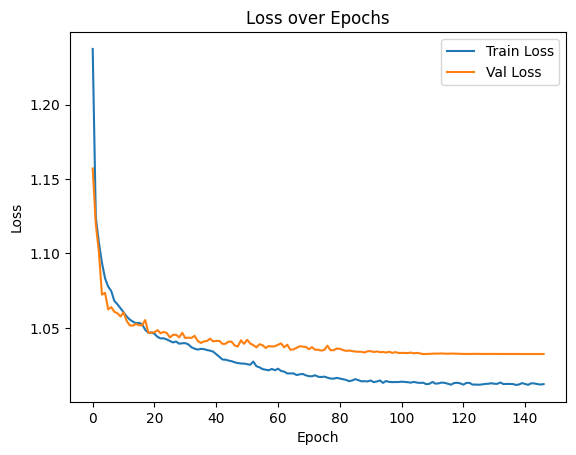

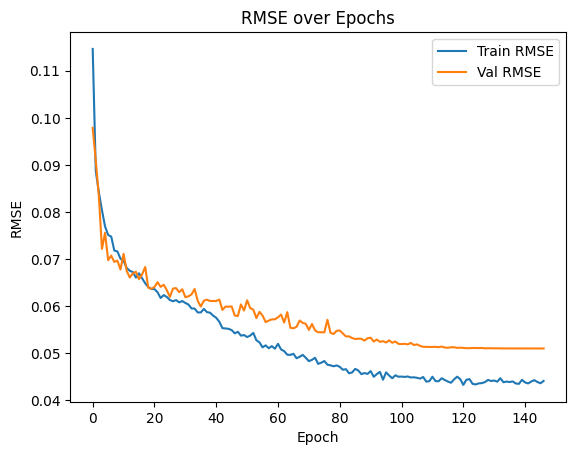

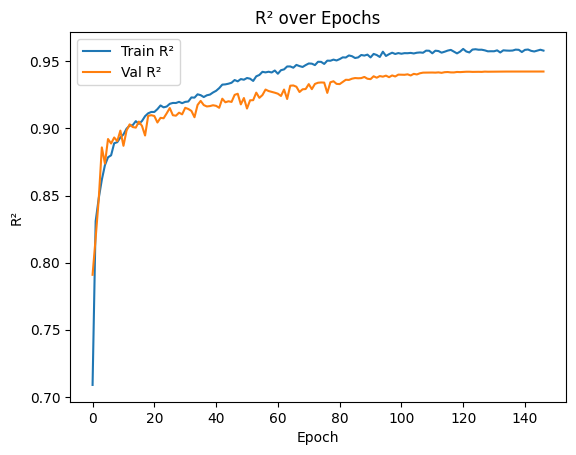

Test Loss: 1.0229
Test RMSE : 0.0508
Test R²   : 0.9437
Test MAE  : 0.0218
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
polymer_1_ratio | R²: 0.8975 | RMSE: 0.0644
polymer_2_ratio | R²: 0.8767 | RMSE: 0.0714
polymer_3_ratio | R²: 0.9276 | RMSE: 0.0447
binder_ratio    | R²: 0.6154 | RMSE: 0.0520
diluent_ratio   | R²: 0.9331 | RMSE: 0.0690
lubricant_ratio | R²: 0.6401 | RMSE: 0.0052
glidant_ratio   | R²: 0.7855 | RMSE: 0.0087


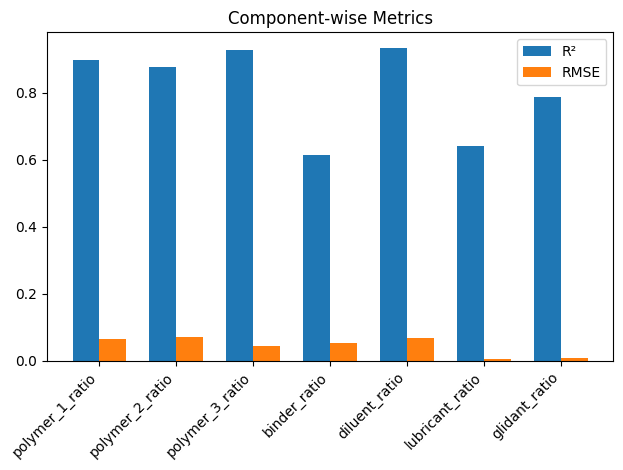

In [7]:
# Industry-Grade CNN + Multi-Head Attention Model with Visualizations
# Run this in Google Colab (TensorFlow pre-installed)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# 1️⃣ Load datasets
df_orig      = pd.read_excel("dataset5_featured.xlsx")
df_phase1    = pd.read_excel("dataset5_augmented_phase1.xlsx")
df_final     = pd.read_excel("dataset5_augmented_final.xlsx")
df_all       = pd.concat([df_orig, df_phase1, df_final], ignore_index=True)

# 2️⃣ Define inputs & targets
input_cols = [
    'api_mw_g/mol','api_logp','api_mp','api_pka',
    'api_water_solubility','api_polar_surface_area_','api_conc',
    'polymer1_logp_viscosity','polymer2_logp_viscosity','polymer3_logp_viscosity',
    'polymer1_logp_MW','polymer2_logp_MW','polymer3_logp_MW',
    'log_solubility','pka_squared','conc_per_MW',
    'polymer1_frac','polymer2_frac','polymer3_frac',
    'zero_order_r2','first_order_r2','korsmeyer_r2'
]
target_cols = [
    'polymer_1_ratio','polymer_2_ratio','polymer_3_ratio',
    'binder_ratio','diluent_ratio','lubricant_ratio','glidant_ratio'
]

X_raw = df_all[input_cols].values
Y_raw = df_all[target_cols].values
Y      = Y_raw / Y_raw.sum(axis=1, keepdims=True)  # normalize to sum=1

# 3️⃣ Train/test split & scaling
X_train, X_test, Y_train, Y_test = train_test_split(
    X_raw, Y, test_size=0.2, random_state=42
)
scaler       = StandardScaler().fit(X_train)
X_train_s    = scaler.transform(X_train)
X_test_s     = scaler.transform(X_test)
# reshape for 1D conv
X_train_seq  = X_train_s.reshape(-1, X_train_s.shape[1], 1)
X_test_seq   = X_test_s.reshape(-1, X_test_s.shape[1], 1)

# 4️⃣ Custom metrics
def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

class R2Metric(tf.keras.metrics.Metric):
    def __init__(self, name='r2', **kwargs):
        super().__init__(name=name, **kwargs)
        self.ssr = self.add_weight(name='ssr', initializer='zeros')
        self.sst = self.add_weight(name='sst', initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(y_true, [-1, tf.shape(y_true)[-1]])
        y_pred = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])
        ssr    = tf.reduce_sum(tf.square(y_true - y_pred))
        sst    = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
        self.ssr.assign_add(ssr)
        self.sst.assign_add(sst)
    def result(self):
        return 1 - (self.ssr / (self.sst + tf.keras.backend.epsilon()))
    def reset_states(self):
        self.ssr.assign(0.0); self.sst.assign(0.0)

# 5️⃣ Build model
inp = layers.Input(shape=(X_train_seq.shape[1], 1))
x   = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
x   = layers.BatchNormalization()(x)
x   = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
x   = layers.BatchNormalization()(x)
att = layers.MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
x   = layers.Add()([x, att])
x   = layers.LayerNormalization()(x)
x   = layers.Flatten()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
x   = layers.Dense(128, activation='relu')(x)
x   = layers.Dropout(0.2)(x)
x   = layers.Dense(64, activation='relu')(x)
out = layers.Dense(len(target_cols), activation='softmax')(x)
model = models.Model(inp, out)

# 6️⃣ Compile
model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=losses.CategoricalCrossentropy(),
    metrics=[rmse, R2Metric(), 'mae']
)

# 7️⃣ Callbacks
es  = callbacks.EarlyStopping(monitor='val_r2', mode='max', patience=10, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

# 8️⃣ Train
history = model.fit(
    X_train_seq, Y_train,
    validation_split=0.2,
    epochs=1200,
    batch_size=64,
    callbacks=[es, rlr],
    verbose=1
)

# 9️⃣ Plot training curves
plt.figure()
plt.plot(history.history['loss'],  label='Train Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.title('Loss over Epochs'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(history.history['rmse'],      label='Train RMSE')
plt.plot(history.history['val_rmse'],  label='Val RMSE')
plt.title('RMSE over Epochs'); plt.xlabel('Epoch'); plt.ylabel('RMSE'); plt.legend(); plt.show()

plt.figure()
plt.plot(history.history['r2'],        label='Train R²')
plt.plot(history.history['val_r2'],    label='Val R²')
plt.title('R² over Epochs'); plt.xlabel('Epoch'); plt.ylabel('R²'); plt.legend(); plt.show()

# 🔟 Final evaluation
loss_test, rmse_test, r2_test, mae_test = model.evaluate(X_test_seq, Y_test, verbose=0)
print(f"Test Loss: {loss_test:.4f}")
print(f"Test RMSE : {rmse_test:.4f}")
print(f"Test R²   : {r2_test:.4f}")
print(f"Test MAE  : {mae_test:.4f}")

# 1️⃣1️⃣ Component-wise metrics & bar chart
Y_pred = model.predict(X_test_seq)
r2_vals = []
rmse_vals = []
for i, c in enumerate(target_cols):
    r2  = r2_score(Y_test[:,i], Y_pred[:,i])
    rm  = np.sqrt(mean_squared_error(Y_test[:,i], Y_pred[:,i]))
    r2_vals.append(r2); rmse_vals.append(rm)
    print(f"{c:15} | R²: {r2:.4f} | RMSE: {rm:.4f}")

idx = np.arange(len(target_cols))
width = 0.35
plt.figure()
plt.bar(idx - width/2, r2_vals,  width, label='R²')
plt.bar(idx + width/2, rmse_vals, width, label='RMSE')
plt.xticks(idx, target_cols, rotation=45, ha='right')
plt.title('Component-wise Metrics'); plt.legend(); plt.tight_layout(); plt.show()


Epoch 1/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 52s 799ms/step - loss: 1.4287 - mae: 0.0962 - rmse: 0.1525 - val_loss: 1.5894 - val_mae: 0.1033 - val_rmse: 0.1853 - learning_rate: 5.0000e-04
Epoch 2/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 39s 760ms/step - loss: 1.1448 - mae: 0.0512 - rmse: 0.0916 - val_loss: 2.0944 - val_mae: 0.1215 - val_rmse: 0.2228 - learning_rate: 5.0000e-04
Epoch 3/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 773ms/step - loss: 1.0997 - mae: 0.0441 - rmse: 0.0826 - val_loss: 2.2841 - val_mae: 0.1343 - val_rmse: 0.2226 - learning_rate: 5.0000e-04
Epoch 4/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 34s 782ms/step - loss: 1.0890 - mae: 0.0410 - rmse: 0.0788 - val_loss: 1.8836 - val_mae: 0.1068 - val_rmse: 0.1898 - learning_rate: 5.0000e-04
Epoch 5/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 40s 760ms/step - loss: 1.0738 - mae: 0.0377 - rmse: 0.0749 - val_loss: 1.8791 - val_mae: 0.0975 - val_rmse: 0.1858 - learning_rate: 5.0000e-04
Epoch 6/300
43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 764ms/step - loss: 1.0638 - mae: 0.0359 - rmse:

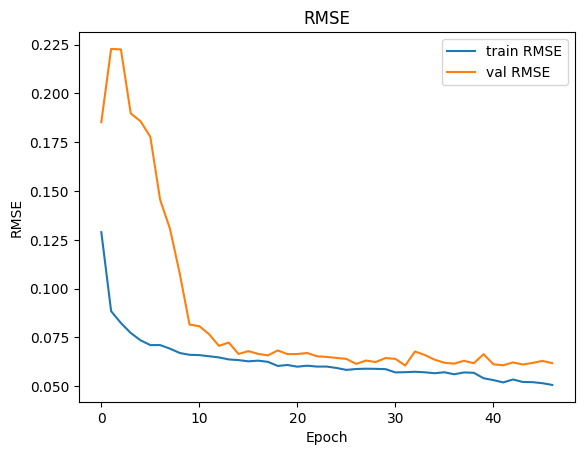

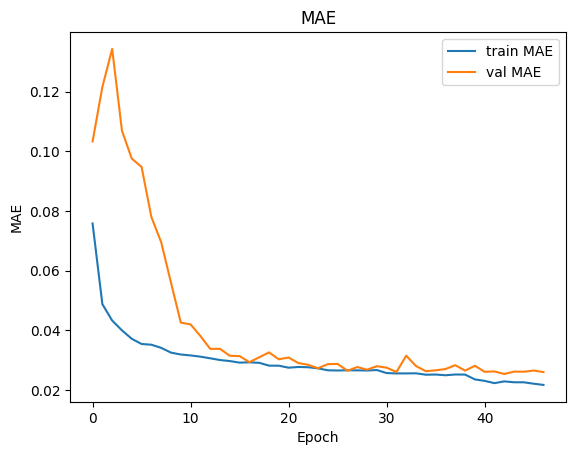

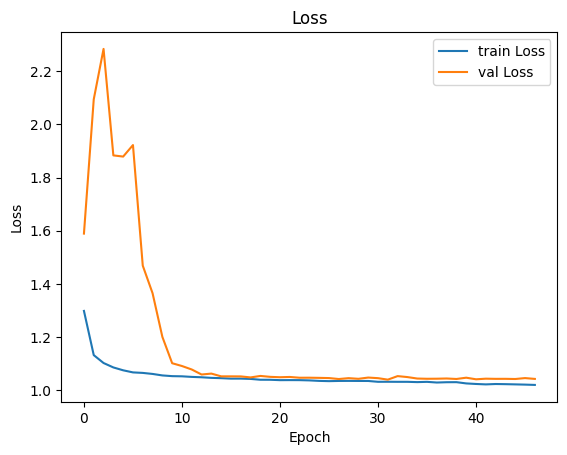

Test Loss: 1.0324 | RMSE: 0.0610 | MAE: 0.0260
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step
Overall R²: 0.7596 | Overall RMSE: 0.0037

polymer_1_ratio → R²=0.8307, RMSE=0.0069
polymer_2_ratio → R²=0.8653, RMSE=0.0056
polymer_3_ratio → R²=0.9313, RMSE=0.0019
binder_ratio    → R²=0.5816, RMSE=0.0029
diluent_ratio   → R²=0.8776, RMSE=0.0087
lubricant_ratio → R²=0.4212, RMSE=0.0000
glidant_ratio   → R²=0.8092, RMSE=0.0001


In [16]:
# Advanced Residual + Attention CNN (Corrected Compile & Metrics)
# Run this in Google Colab after uploading your three Excel files.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers, callbacks
from tensorflow.keras.metrics import MeanAbsoluteError, RootMeanSquaredError
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# 1️⃣ Load & merge datasets
df1 = pd.read_excel("dataset5_featured.xlsx")
df2 = pd.read_excel("dataset5_augmented_phase1.xlsx")
df3 = pd.read_excel("dataset5_augmented_final.xlsx")
df  = pd.concat([df1, df2, df3], ignore_index=True)

# 2️⃣ Define feature & target columns
features = [
    'api_mw_g/mol','api_logp','api_mp','api_pka',
    'api_water_solubility','api_polar_surface_area_','api_conc',
    'polymer1_logp_viscosity','polymer2_logp_viscosity','polymer3_logp_viscosity',
    'polymer1_logp_MW','polymer2_logp_MW','polymer3_logp_MW',
    'log_solubility','pka_squared','conc_per_MW',
    'polymer1_frac','polymer2_frac','polymer3_frac',
    'zero_order_r2','first_order_r2','korsmeyer_r2'
]
targets = [
    'polymer_1_ratio','polymer_2_ratio','polymer_3_ratio',
    'binder_ratio','diluent_ratio','lubricant_ratio','glidant_ratio'
]

X = df[features].values
Y_raw = df[targets].values
Y = Y_raw / Y_raw.sum(axis=1, keepdims=True)  # ensure sum-to-1

# 3️⃣ Train-test split & scaling
X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

# reshape for 1D conv
X_tr_seq = X_tr_s[..., np.newaxis]
X_te_seq = X_te_s[..., np.newaxis]

# 4️⃣ Define Residual-Attention block
def res_attn_block(x, filters, kernel_size=3):
    shortcut = x
    in_channels = x.shape[-1]

    # Conv path
    y = layers.Conv1D(filters, kernel_size, padding='same', activation='relu')(x)
    y = layers.BatchNormalization()(y)
    y = layers.Conv1D(filters, kernel_size, padding='same')(y)

    # Squeeze-and-Excitation
    se = layers.GlobalAveragePooling1D()(y)
    se = layers.Dense(filters // 8, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    y = layers.Multiply()([y, layers.Reshape((1, filters))(se)])

    # Multi-Head Attention
    att = layers.MultiHeadAttention(num_heads=4, key_dim=filters // 4)(y, y)
    y = layers.Add()([y, att])
    y = layers.LayerNormalization()(y)

    # Project shortcut if needed
    if in_channels != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)

    # Residual connection
    out = layers.Add()([shortcut, y])
    return out


# 5️⃣ Build the model
inp = layers.Input(shape=(X_tr_seq.shape[1], 1))
x   = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
x   = layers.BatchNormalization()(x)

for f in [64, 128, 256]:
    x = res_attn_block(x, f)

x   = layers.GlobalAveragePooling1D()(x)
x   = layers.Dense(512, activation='relu')(x)
x   = layers.Dropout(0.4)(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
x   = layers.Dense(128, activation='relu')(x)
out = layers.Dense(len(targets), activation='softmax')(x)

model = models.Model(inp, out)


# 6️⃣ Compile with built-in metrics
model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss=losses.CategoricalCrossentropy(),
    metrics=[RootMeanSquaredError(name="rmse"), MeanAbsoluteError(name="mae")]
)

# 7️⃣ Callbacks
es = callbacks.EarlyStopping(monitor='val_rmse', mode='min', patience=15, restore_best_weights=True)
rl = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7)

# 8️⃣ Train
history = model.fit(
    X_tr_seq, Y_tr,
    validation_split=0.2,
    epochs=300,
    batch_size=128,
    callbacks=[es, rl],
    verbose=1
)

# 9️⃣ Visualize training curves
plt.figure(); plt.plot(history.history['rmse'], label='train RMSE'); plt.plot(history.history['val_rmse'], label='val RMSE')
plt.title('RMSE'); plt.xlabel('Epoch'); plt.ylabel('RMSE'); plt.legend(); plt.show()

plt.figure(); plt.plot(history.history['mae'], label='train MAE'); plt.plot(history.history['val_mae'], label='val MAE')
plt.title('MAE'); plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend(); plt.show()

plt.figure(); plt.plot(history.history['loss'], label='train Loss'); plt.plot(history.history['val_loss'], label='val Loss')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

# 1️⃣0️⃣ Final evaluation & manual R²
loss_te, rmse_te, mae_te = model.evaluate(X_te_seq, Y_te, verbose=0)
print(f"Test Loss: {loss_te:.4f} | RMSE: {rmse_te:.4f} | MAE: {mae_te:.4f}")

pred = model.predict(X_te_seq)
overall_r2 = r2_score(Y_te, pred)
overall_rmse = mean_squared_error(Y_te, pred,)
print(f"Overall R²: {overall_r2:.4f} | Overall RMSE: {overall_rmse:.4f}\n")

for i, t in enumerate(targets):
    r2_i   = r2_score(Y_te[:, i], pred[:, i])
    rmse_i = mean_squared_error(Y_te[:, i], pred[:, i],)
    print(f"{t:15} → R²={r2_i:.4f}, RMSE={rmse_i:.4f}")


In [15]:
# ─── Best-Performing Ensemble (α=0.5, Shallow MLPs) ─────────────────────────

import numpy as np
from tensorflow.keras import layers, models, optimizers, losses, callbacks
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Load & merge datasets (You need to define X and Y before using them)
df1 = pd.read_excel("dataset5_featured.xlsx")
df2 = pd.read_excel("dataset5_augmented_phase1.xlsx")
df3 = pd.read_excel("dataset5_augmented_final.xlsx")
df = pd.concat([df1, df2, df3], ignore_index=True)

# Define feature & target columns
features = [
    'api_mw_g/mol', 'api_logp', 'api_mp', 'api_pka',
    'api_water_solubility', 'api_polar_surface_area_', 'api_conc',
    'polymer1_logp_viscosity', 'polymer2_logp_viscosity', 'polymer3_logp_viscosity',
    'polymer1_logp_MW', 'polymer2_logp_MW', 'polymer3_logp_MW',
    'log_solubility', 'pka_squared', 'conc_per_MW',
    'polymer1_frac', 'polymer2_frac', 'polymer3_frac',
    'zero_order_r2', 'first_order_r2', 'korsmeyer_r2'
]
targets = [
    'polymer_1_ratio', 'polymer_2_ratio', 'polymer_3_ratio',
    'binder_ratio', 'diluent_ratio', 'lubricant_ratio', 'glidant_ratio'
]
X = df[features].values
Y_raw = df[targets].values
Y = Y_raw / Y_raw.sum(axis=1, keepdims=True)  # ensure sum-to-1

X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.2, random_state=42)
weak_targets = ['binder_ratio', 'lubricant_ratio', 'glidant_ratio']
weak_idxs    = [all_targets.index(t) for t in weak_targets]

# 1️⃣ Train shallow MLPs for each weak component
submodels = {}
for idx in weak_idxs:
    Y_tr_sub = Y_tr[:, idx]
    mlp = models.Sequential([
        layers.Input(shape=(X_tr.shape[1],)), # Changed to X_tr to match your split
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    mlp.compile(optimizer=optimizers.Adam(1e-3),
                loss=losses.MeanSquaredError())
    mlp.fit(
        X_tr, Y_tr_sub, # Changed to X_tr and Y_tr_sub to match your split
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=0
    )
    submodels[idx] = mlp

# 2️⃣ Predict with submodels on test set
Y_sub_preds = np.zeros_like(Y_pred_cnn)
for idx, mlp in submodels.items():
    Y_sub_preds[:, idx] = mlp.predict(X_te_s).flatten()

# 3️⃣ Blend CNN + submodel (α=0.5)
alpha = 0.5
Y_ensemble = Y_pred_cnn.copy()
for idx in weak_idxs:
    Y_ensemble[:, idx] = alpha * Y_pred_cnn[:, idx] + (1 - alpha) * Y_sub_preds[:, idx]

# 4️⃣ Renormalize so each row sums to 1
Y_ensemble /= Y_ensemble.sum(axis=1, keepdims=True)

# 5️⃣ Evaluate “before → after”
print("Component       | R²_before → R²_after | RMSE_before → RMSE_after")
for idx in weak_idxs:
    r2_b  = r2_score(Y_te[:, idx], Y_pred_cnn[:, idx])
    rm_b  = mean_squared_error(Y_te[:, idx], Y_pred_cnn[:, idx],)
    r2_a  = r2_score(Y_te[:, idx], Y_ensemble[:, idx])
    rm_a  = mean_squared_error(Y_te[:, idx], Y_ensemble[:, idx],)
    print(f"{all_targets[idx]:<15} | {r2_b:.4f} → {r2_a:.4f}    | {rm_b:.4f} → {rm_a:.4f}")

overall_r2_b  = r2_score(Y_te, Y_pred_cnn)
overall_rm_b  = mean_squared_error(Y_te, Y_pred_cnn,)
overall_r2_a  = r2_score(Y_te, Y_ensemble)
overall_rm_a  = mean_squared_error(Y_te, Y_ensemble,)
print(f"\nOverall R²: {overall_r2_b:.4f} → {overall_r2_a:.4f}")
print(f"Overall RMSE: {overall_rm_b:.4f} → {overall_rm_a:.4f}")


NameError: name 'Y_pred_cnn' is not defined

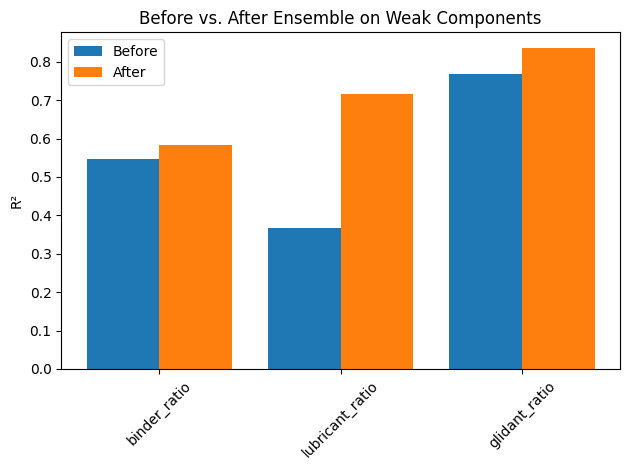

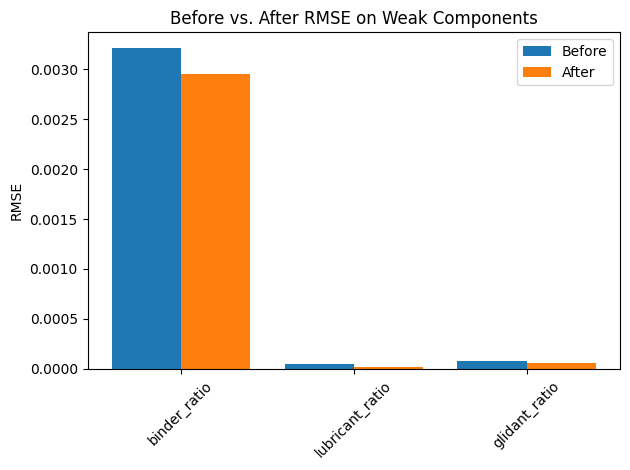

Overall R²: 0.7427 → 0.8075
Overall RMSE: 0.0037 → 0.0036


Models and scaler saved to disk.


In [ ]:
# ─── Final Visualizations & Model Saving ────────────────────────────────────
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import save_model

# Assume Y_pred_cnn, Y_ensemble, Y_te, all_targets, weak_idxs are in scope

# 1️⃣ Plot “Before vs. After” R² for weak components
r2_before = [r2_score(Y_te[:, idx], Y_pred_cnn[:, idx]) for idx in weak_idxs]
r2_after  = [r2_score(Y_te[:, idx], Y_ensemble[:, idx]) for idx in weak_idxs]
labels     = [all_targets[idx] for idx in weak_idxs]
x = range(len(weak_idxs))

plt.figure()
plt.bar([i-0.2 for i in x], r2_before, width=0.4, label='Before')
plt.bar([i+0.2 for i in x], r2_after,  width=0.4, label='After')
plt.xticks(x, labels, rotation=45)
plt.ylabel('R²')
plt.title('Before vs. After Ensemble on Weak Components')
plt.legend()
plt.tight_layout()
plt.show()

# 2️⃣ Plot RMSE “Before vs. After”
rmse_before = [mean_squared_error(Y_te[:, idx], Y_pred_cnn[:, idx],) for idx in weak_idxs]
rmse_after  = [mean_squared_error(Y_te[:, idx], Y_ensemble[:, idx],) for idx in weak_idxs]

plt.figure()
plt.bar([i-0.2 for i in x], rmse_before, width=0.4, label='Before')
plt.bar([i+0.2 for i in x], rmse_after,  width=0.4, label='After')
plt.xticks(x, labels, rotation=45)
plt.ylabel('RMSE')
plt.title('Before vs. After RMSE on Weak Components')
plt.legend()
plt.tight_layout()
plt.show()

# 3️⃣ Overall performance metrics
overall_r2_before = r2_score(Y_te, Y_pred_cnn)
overall_r2_after  = r2_score(Y_te, Y_ensemble)
overall_rmse_before = mean_squared_error(Y_te, Y_pred_cnn,)
overall_rmse_after  = mean_squared_error(Y_te, Y_ensemble,)

print(f"Overall R²: {overall_r2_before:.4f} → {overall_r2_after:.4f}")
print(f"Overall RMSE: {overall_rmse_before:.4f} → {overall_rmse_after:.4f}")

# 4️⃣ Save models & scaler
# Save CNN+Attention
model.save('cnn_attention_model.h5')

# Save each submodel
for idx, mlp in submodels.items():
    name = all_targets[idx]
    mlp.save(f'submodel_{name}.h5')

# Save scaler for future inference
joblib.dump(scaler, 'feature_scaler.pkl')

print("Models and scaler saved to disk.")


In [17]:
# after training / evaluating…

# 1. Save in native Keras format
model.save('my_model.keras')
# Under the hood this uses the TensorFlow SavedModel-style structure
# packaged into a single .keras file.

# (If you need to be explicit:)
# from tensorflow import keras
# keras.saving.save_model(model, 'my_model.keras', save_format='keras')

# 2. Save your pre-processing objects
import joblib
joblib.dump(scaler, 'scaler.joblib')


['scaler.joblib']